In [ ]:
# =========  preprocess =========
from collections import Counter
import numpy as np
import jieba
import re
import pandas as pd
import os
import torch
import random

def set_seed(seed=142):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)    

# file path
data_path = '/kaggle/input/douban-mgh'
train_file = 'train_pinggu.csv'
valid_file = 'test_pinggu.csv'
test_file = 'test_pinggu.csv'

train_df = pd.read_csv(os.path.join(data_path, train_file)) 

# Stop vocabulary loading
with open('/kaggle/input/cn-stopwords/cn_stopwords.txt', encoding='utf-8') as f:
    stop_words = set(line.strip() for line in f if line.strip())


# word frequency statistic
def get_word_freq(texts):
    all_tokens = []
    for text in texts:
        x = re.sub(r"[^\u4e00-\u9fa5]", "", str(text))
        tokens = jieba.lcut(x)
        all_tokens.extend(tokens)
    return Counter(all_tokens)

word_freq = get_word_freq(train_df['text'].tolist()) 

In [ ]:
# ========= Configuration parameters =========

# Hyperparameters
fix_length = 64
batch_size = 64  
label_list = ['negative', 'positive']
class_number = len(label_list)
epochs = 60
#learning_rate = 3e-4
#learning_rate =2e-4
learning_rate =1e-3

# ========= jieba_tokenize+ Customize Dataset=========
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import jieba
import re


def jieba_tokenize(x, word_freq=None):
    x = re.sub('[^\u4e00-\u9fa5]', "", str(x))
    tokens = jieba.lcut(x)
    
    if word_freq:
        tokens = [
            t for t in tokens 
            if word_freq[t] < 10000  # Custom frequency range
            and t not in stop_words
            and len(t) > 1
        ]
    else:
        tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    
    return tokens

from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-chinese")

class CommentDataset(Dataset):
    def __init__(self, texts, labels, word_freq=None, max_len=256):
        #jieba_tokenize + cleaning
        texts = [" ".join(jieba_tokenize(t, word_freq)) for t in texts]
        self.encodings = tokenizer(
            texts,
            padding='max_length',
            truncation=True,
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item
        
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy

class TextCNN(nn.Module):
    def __init__(self, vocab_size=21128, embed_dim=64, class_num=2, 
                 kernel_nums=32, kernel_sizes=[2,3,4,5], dropout=0.4):  
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(1, kernel_nums, (k, embed_dim)),
                nn.BatchNorm2d(kernel_nums),
                nn.ReLU()
            ) for k in kernel_sizes
        ])
        
        self.fc = nn.Sequential(
            nn.Linear(len(kernel_sizes) * kernel_nums, 64),  
            nn.ReLU(),                                       
            nn.Linear(64, class_num)                        
        )
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, input_ids):
        # [batch, seq_len] -> [batch, 1, seq_len, embed_dim]
        x = self.embedding(input_ids).unsqueeze(1)  
        
        conv_outputs = []
        for conv in self.convs:
            conv_out = conv(x).squeeze(3)          # [batch, knum, seq_len-k+1]
            pooled = F.max_pool1d(conv_out, conv_out.size(2)).squeeze(2)  # [batch, knum]
            conv_outputs.append(pooled)
            
        # [batch, knum * len(kernel_sizes)]
        x = torch.cat(conv_outputs, dim=1)  
        x = self.dropout(x) 
        return self.fc(x)

In [ ]:
# ========== train and test function =========
import torch.nn.functional as F
from sklearn.metrics import classification_report, accuracy_score
from tqdm import tqdm
import matplotlib.pyplot as plt

def train_model(model, train_loader, val_loader, device, name='TextCNN'):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[6, 10], gamma=0.6)
    best_acc = 0
    early_stopping = EarlyStopping(patience=10)

    train_losses = []
    val_accuracies = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        correct = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch}"):
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids)
            loss = F.cross_entropy(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)
        avg_loss = total_loss
        train_losses.append(avg_loss)
        print(f">>> Epoch {epoch} Train Loss: {avg_loss:.4f}, Accuracy: {train_acc:.4f}")

        # evaluate
        val_acc = evaluate_model(model, val_loader, device)
        val_accuracies.append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            print(">>> Best model updated. Saving...")
            torch.save(model.state_dict(), f"{name}_model.pt")

        scheduler.step()

        early_stopping(val_acc, model, path=f"{name}_model.pt")
        if early_stopping.early_stop:
            print(">>> Early stopping triggered. Stop training.")
            break

    return train_losses, val_accuracies

def evaluate_model(model, dataloader, device):
    model.eval()
    correct = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
    acc = correct / len(dataloader.dataset)
    print(f">>> Validation Accuracy: {acc:.4f}")
    return acc

def test_model(model, dataloader, device):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    acc = accuracy_score(y_true, y_pred)
    print(f">>> Test Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=label_list, digits=3))

class EarlyStopping:
    def __init__(self, patience=3, verbose=True):
        self.patience = patience
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.verbose = verbose

    def __call__(self, score, model, path='TextCNN_model.pt'):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.counter = 0
            torch.save(model.state_dict(), path)
            if self.verbose:
                print(f">>> New best score: {score:.4f}, saving model.")
        else:
            self.counter += 1
            if self.verbose:
                print(f">>> No improvement. EarlyStop counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

def plot_training_curve(train_losses, val_accuracies):
    epochs = range(1, len(train_losses)+1)

    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Train Loss", color='tab:red')
    ax1.plot(epochs, train_losses, label="Train Loss", color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    ax2 = ax1.twinx()
    ax2.set_ylabel("Validation Accuracy", color='tab:blue')
    ax2.plot(epochs, val_accuracies, label="Val Accuracy", color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    plt.title("Training Loss & Validation Accuracy")
    fig.tight_layout()
    plt.show()

Epoch 1: 100%|██████████| 1594/1594 [00:11<00:00, 137.43it/s]


>>> Epoch 1 Train Loss: 951.6980, Accuracy: 0.6809
>>> Validation Accuracy: 0.7388
>>> Best model updated. Saving...
>>> New best score: 0.7388, saving model.


Epoch 2: 100%|██████████| 1594/1594 [00:11<00:00, 138.12it/s]


>>> Epoch 2 Train Loss: 858.9035, Accuracy: 0.7312
>>> Validation Accuracy: 0.7540
>>> Best model updated. Saving...
>>> New best score: 0.7540, saving model.


Epoch 3: 100%|██████████| 1594/1594 [00:11<00:00, 138.63it/s]


...

>>> Epoch 26 Train Loss: 649.3411, Accuracy: 0.8103
>>> Validation Accuracy: 0.7708
>>> No improvement. EarlyStop counter: 8/10


Epoch 27: 100%|██████████| 1594/1594 [00:11<00:00, 137.22it/s]


>>> Epoch 27 Train Loss: 645.8833, Accuracy: 0.8105
>>> Validation Accuracy: 0.7684
>>> No improvement. EarlyStop counter: 9/10


Epoch 28: 100%|██████████| 1594/1594 [00:11<00:00, 138.13it/s]


>>> Epoch 28 Train Loss: 642.8698, Accuracy: 0.8114
>>> Validation Accuracy: 0.7701
>>> No improvement. EarlyStop counter: 10/10
>>> Early stopping triggered. Stop training.


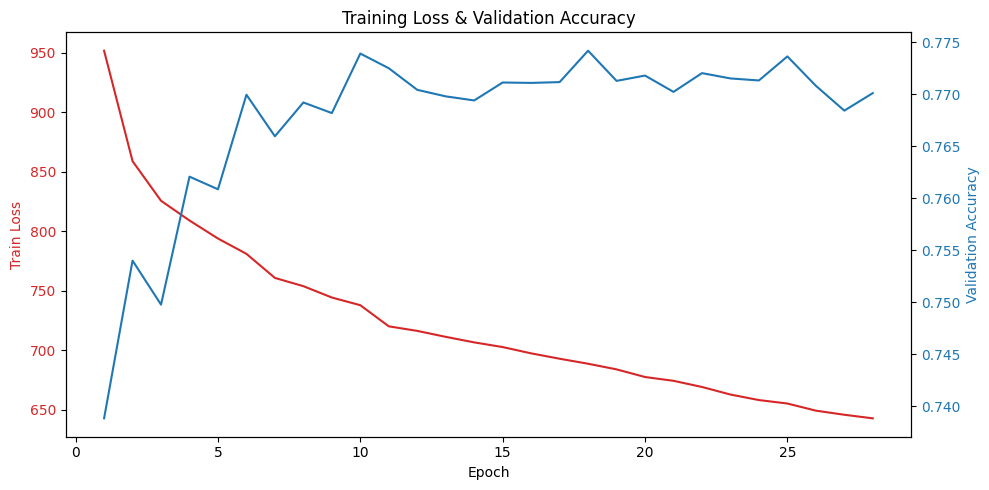

>>> Loading best model and testing...


/tmp/ipykernel_31/3341267017.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("TextCNN_model.pt"))


>>> Test Accuracy: 0.7742
              precision    recall  f1-score   support

    negative      0.749     0.675     0.710     10431
    positive      0.789     0.843     0.815     15073

    accuracy                          0.774     25504
   macro avg      0.769     0.759     0.762     25504
weighted avg      0.773     0.774     0.772     25504



In [ ]:
# =========  main  =========


train_df = pd.read_csv(os.path.join(data_path, train_file))
val_df = pd.read_csv(os.path.join(data_path, valid_file))
test_df = pd.read_csv(os.path.join(data_path, test_file))

train_dataset = CommentDataset(
    texts=train_df['text'].tolist(),
    labels=train_df['label'].tolist(),
    word_freq=word_freq,         
    max_len=fix_length
)
val_dataset = CommentDataset(val_df['text'].tolist(), val_df['label'].tolist(), max_len=fix_length)
test_dataset = CommentDataset(test_df['text'].tolist(), test_df['label'].tolist(), max_len=fix_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# model train
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#model = Transformer()
model = TextCNN()
#model = TextRCNN()
#model = TextRNN()
#model = TextRNN_Attention()
train_losses, val_accuracies = train_model(model, train_loader, val_loader, device, name='TextCNN')
plot_training_curve(train_losses, val_accuracies)
# model test
print(">>> Loading best model and testing...")
#model.load_state_dict(torch.load("Transformer_model.pt"))
model.load_state_dict(torch.load("TextCNN_model.pt"))
#model.load_state_dict(torch.load("TextRCNN_model.pt"))
#model.load_state_dict(torch.load("TextRNN_model.pt"))
#model.load_state_dict(torch.load("TextRNN_Attention_model.pt"))
test_model(model, test_loader, device)